In [16]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [17]:
#define state
class BMIState(TypedDict):

    
    weight_kg: float
    height_m:float
    bmi:float
    category:str

In [18]:
def calculate_bmi(State: BMIState)-> BMIState:
    weight=State['weight_kg']
    height=State['height_m']

    bmi=weight/(height**2)
    State['bmi']=round(bmi,2)

    return State

In [19]:
def user_category(state:BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

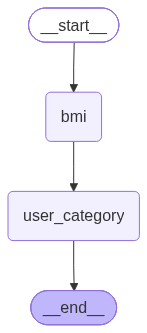

In [20]:
#define your graph
graph=StateGraph(BMIState)

#add nodes to your graph
graph.add_node('bmi',calculate_bmi)
graph.add_node("user_category",user_category)

#add edges to your graph
graph.add_edge(START,'bmi')
graph.add_edge('bmi','user_category')
graph.add_edge('user_category',END)

#compile the graph
graph.compile()

In [21]:
#execute the graph
print(graph.compile().invoke({'weight_kg':80,'height_m':1.73}))

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


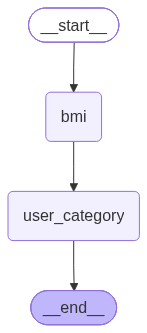

In [22]:
from IPython.display import Image
Image(graph.compile().get_graph().draw_mermaid_png())